<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment_5:EXploratory Data Analysis with Pandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Task 1: Load the Titanic dataset
Task 2: Inspect the data

In [ ]:
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv(url)
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


Display the last 5 rows of the dataset

In [ ]:
df.tail()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.00
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.00
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.45
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.00
886,0,3,Mr. Patrick Dooley,male,32.0,0,0,7.75


Display the data types of each column

In [ ]:
df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
Siblings/Spouses Aboard,int64
Parents/Children Aboard,int64
Fare,float64


Display summary statistics of the numerical columns

In [ ]:
df.describe()

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


Task 3: Clean and preprocess the data

Create a new categorical feature 'PclassCategory' from 'Pclass'

In [ ]:
df['PclassCategory'] = df['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})
df.head(2)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,Third,Unknown,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,First,Unknown,1


Create a new categorical feature 'CabinCategory' from 'Cabin'

In [ ]:
if 'Cabin' in df.columns:
   df['CabinCategory'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'Unknown')
else:
    df['CabinCategory'] = 'Unknown'
df.head(1)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.25,Third,Unknown,1


Handle missing values in the 'Age' column (use mean age)

In [ ]:
df['Age'].fillna(df['Age'].mean(), inplace=True)


Create a 'Family' feature by combining 'SibSp' and 'Parch'

In [ ]:
#df['Family'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard']
df.head(1)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.25,Third,Unknown,1


Task 4: Identify specific data points

Find passengers with the highest fare

In [ ]:
#highest_fare = df[df['Fare'] == df['Fare'].max()]
highest_fare.head(2)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
257,1,1,Miss. Anna Ward,female,35.0,0,0,512.3292,First,Unknown,0
676,1,1,Mr. Thomas Drake Martinez Cardeza,male,36.0,0,1,512.3292,First,Unknown,1


Find passengers with the largest family size

In [ ]:
largest_family = df[df['Family'] == df['Family'].max()]
largest_family.head(2)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
158,0,3,Master. Thomas Henry Sage,male,5.0,8,2,69.55,Third,Unknown,10
179,0,3,Miss. Constance Gladys Sage,female,8.0,8,2,69.55,Third,Unknown,10


Task 5: Demonstrate Pandas Series and DataFrame functionalities

Create a Pandas Series of passenger names

In [ ]:
name_series = df['Name']
name_series.head(3)

,Name
0,Mr. Owen Harris Braund
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...
2,Miss. Laina Heikkinen


Create a DataFrame of passenger names and ages

In [ ]:
names_ages_df = df[['Name', 'Age']]
names_ages_df.head(3)

,Name,Age
0,Mr. Owen Harris Braund,22.0
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,38.0
2,Miss. Laina Heikkinen,26.0


Slice the DataFrame to show only passengers older than 50

In [ ]:
older_passengers = df[df['Age'] > 50]
older_passengers

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,First,Unknown,0
11,1,1,Miss. Elizabeth Bonnell,female,58.0,0,0,26.5500,First,Unknown,0
15,1,2,Mrs. (Mary D Kingcome) Hewlett,female,55.0,0,0,16.0000,Second,Unknown,0
33,0,2,Mr. Edward H Wheadon,male,66.0,0,0,10.5000,Second,Unknown,0
53,0,1,Mr. Engelhart Cornelius Ostby,male,65.0,0,1,61.9792,First,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...
816,1,1,Mrs. Charles Melville (Clara Jennings Gregg) Hays,female,52.0,1,1,93.5000,First,Unknown,2
825,1,1,Mrs. George Nelson (Martha Evelyn) Stone,female,62.0,0,0,80.0000,First,Unknown,0
847,0,3,Mr. Johan Svensson,male,74.0,0,0,7.7750,Third,Unknown,0
853,1,1,Mr. Peter Denis Daly,male,51.0,0,0,26.5500,First,Unknown,0


Task 6: Introduce multi-indexing

Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'

In [ ]:
multi_index_df = df.groupby(['Sex', 'Pclass']).mean(numeric_only=True)
multi_index_df.head(2)

Survived        Age  Siblings/Spouses Aboard  \
Sex    Pclass                                                 
female 1       0.968085  35.255319                 0.553191   
       2       0.921053  28.980263                 0.486842   

               Parents/Children Aboard        Fare    Family  
Sex    Pclass                                                 
female 1                      0.457447  106.125798  1.010638  
       2                      0.605263   21.970121  1.092105

 Task 7: Visualizations

Create a histogram of passenger ages


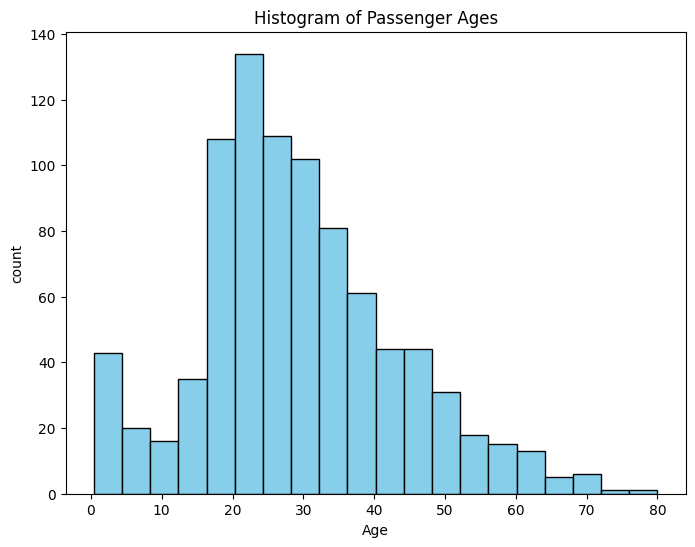

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('count')
plt.show()


Create a bar plot of survival rates by passenger class

<function matplotlib.pyplot.show(close=None, block=None)>

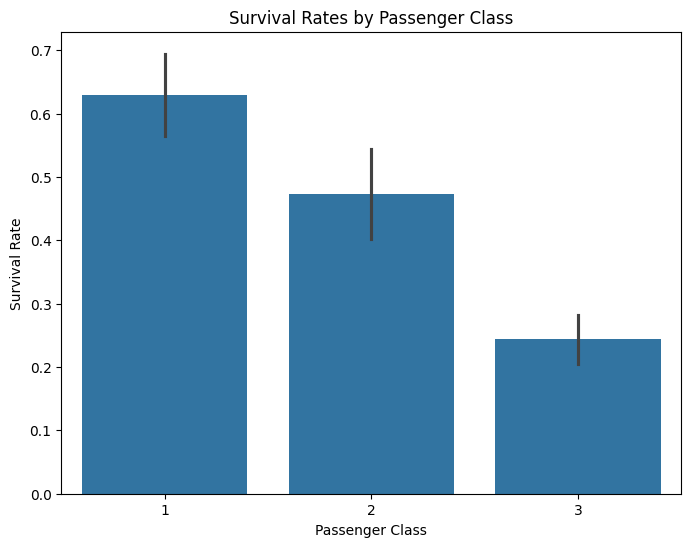

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show

Create a heatmap of correlation between numerical features

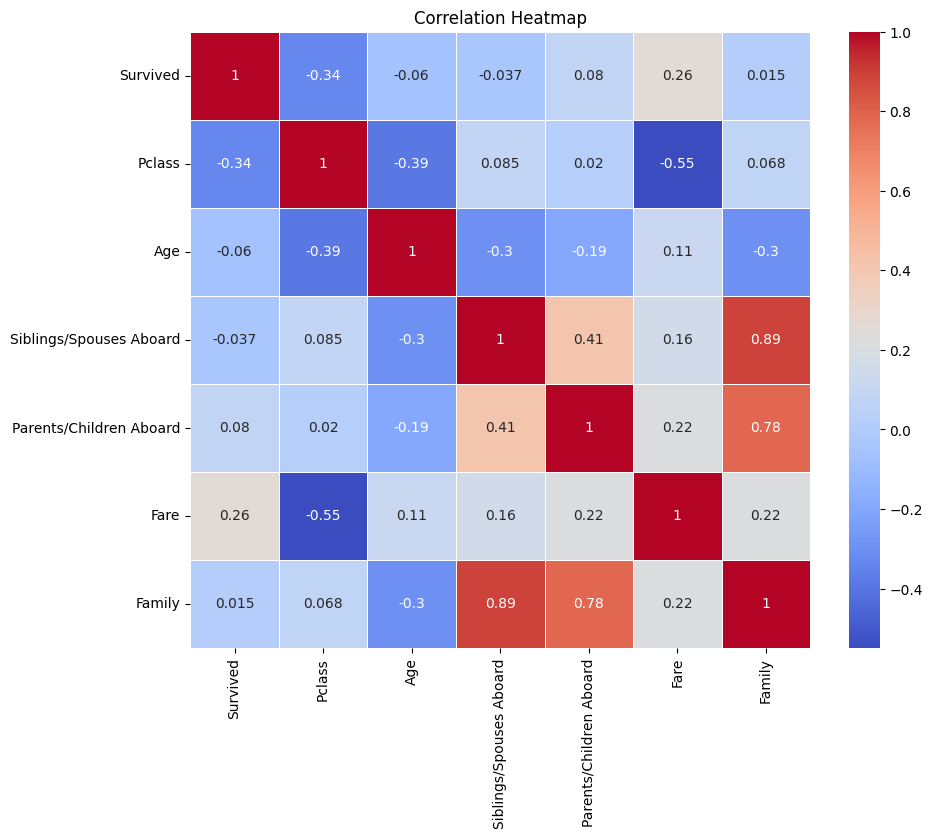

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'

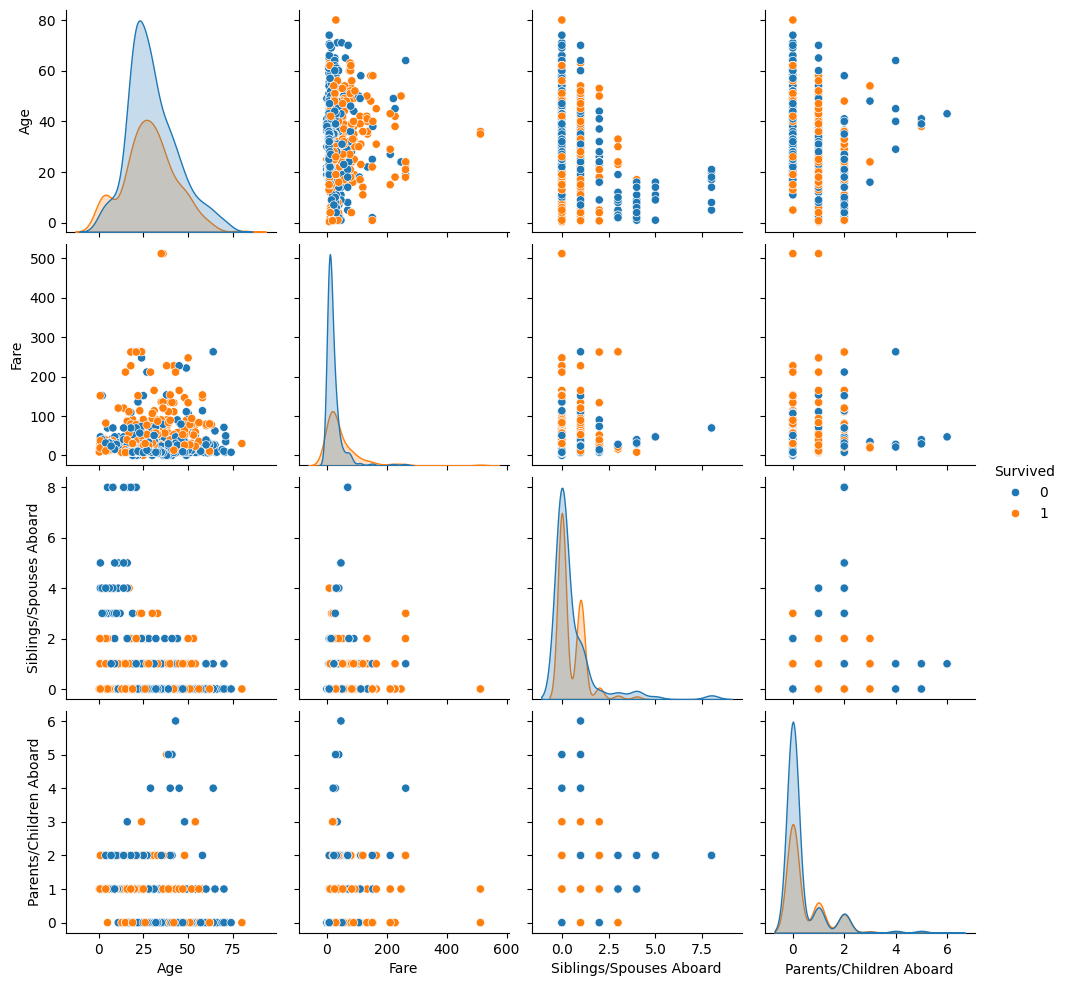

In [ ]:
sns.pairplot(df, hue='Survived', vars=['Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard'])
plt.show()

Task 8: Analyze survival rates

Calculate and display survival rates by sex

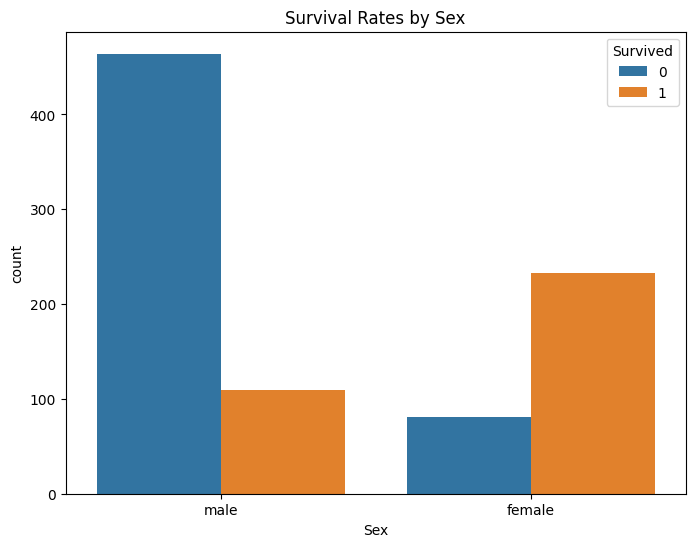

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Rates by Sex')
plt.xlabel('Sex')
plt.ylabel('count')
plt.show()

Calculate and display survival rates by passenger class

In [ ]:
survival_by_class = df.groupby('Pclass')['Survived'].mean()
survival_by_class

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.244353


Task 9: Analyze age distribution

Create a box plot of age distribution by passenger class and sex

Text(0, 0.5, 'Age')

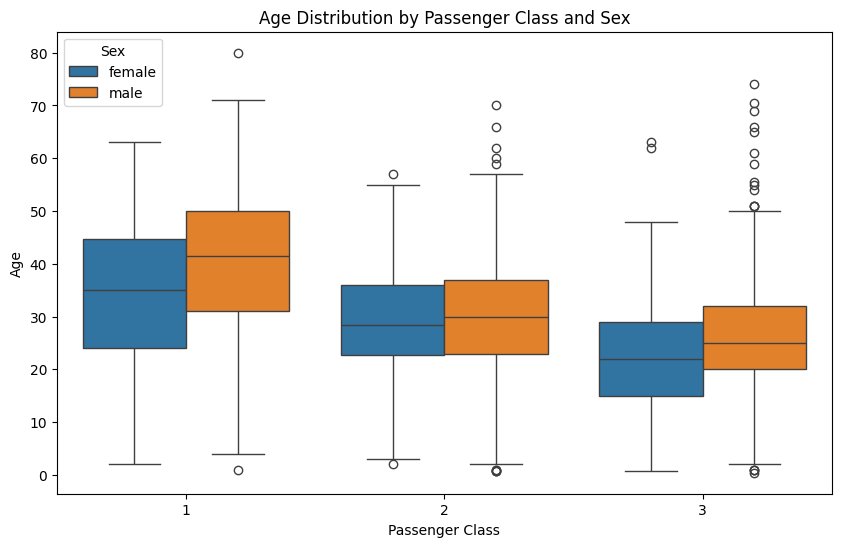

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=df)
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')

Task 10: Analyze fare distribution

Create a violin plot of fare distribution by passenger class and survival status

Text(0.5, 1.0, 'Fare Distribution by Passenger Class and Survival Status')

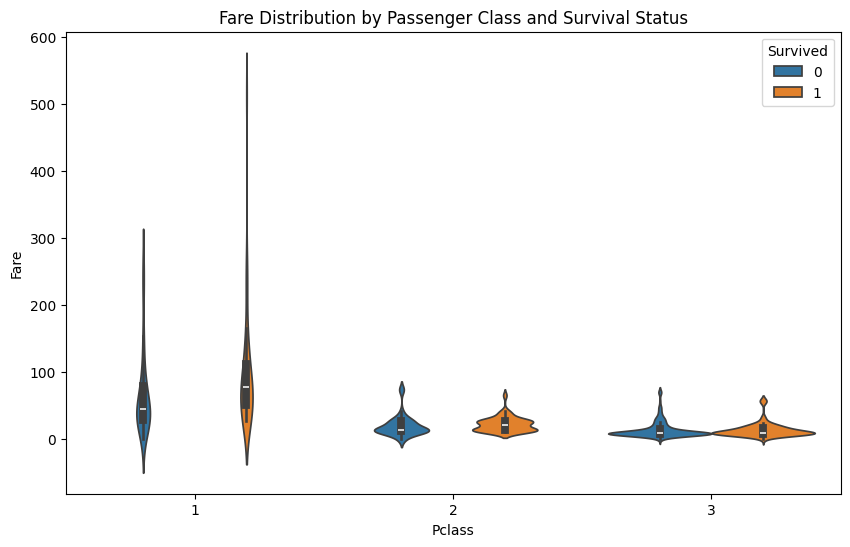

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Pclass', y='Fare', hue='Survived', data=df)
plt.title('Fare Distribution by Passenger Class and Survival Status')